## 1. Préparation de l'environnement et des données
On commence par les bases : importer les librairies et charger notre dataset, DermaMNIST. C'est un jeu de données d'images de lésions cutanées. Notre mission : les classifier correctement, même avec une poignée de labels.

DermaMNIST fait partie de la famille des datasets MedMNIST, une collection standardisée de datasets d'images médicales, tous au format 28x28 et organisés de manière similaire aux célèbres datasets MNIST. L'objectif de MedMNIST est de faciliter la recherche et la comparaison de modèles d'apprentissage automatique sur des tâches médicales.

Le dataset DermaMNIST est basé sur le HAM10000, une large collection d'images de dermatoscopie. Il contient des images de 7 classes différentes de lésions cutanées. Son intérêt pédagogique est majeur : il permet d'aborder des problèmes de classification d'images médicales avec un dataset de taille raisonnable, tout en simulant des scénarios de faible quantité de données labellisées, parfait pour explorer des techniques comme la pseudo-labellisation.

Les 7 classes de lésions cutanées sont :

0: actinic keratoses and intraepithelial carcinoma  
1: basal cell carcinoma  
2: benign keratosis-like lesions  
3: dermatofibroma  
4: melanoma  
5: melanocytic nevi   
6: vascular lesions  

In [ ]:
# importation des packages necessaires
!pip install medmnist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import medmnist
from medmnist import INFO, Evaluator
from sklearn.metrics import accuracy_score, f1_score, classification_report
# Pour la reproductibilité, parce qu'on est des gens sérieux
torch.manual_seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.9 MB/s eta 0:00:00


## 2. Chargement du dataset DermaMNIST

In [ ]:
# Nom du dataset à charger
data_flag = 'dermamnist'
# Récupère les informations spécifiques à ce dataset depuis medmnist
info = INFO[data_flag]

# Ajout de prints pour mieux comprendre le dataset
print(f"Dataset chargé : {data_flag}")

# Extraire le type de tache(classification, regression, ....)
task = info['task']
print(f"Type de tâche : {task}")

# Extraire le nombre de canaux des images
n_channels = info['n_channels']
print(f"Nombre de canaux : {n_channels}")

# Extraire la taille des images
#input_shape = info['input_shape']
#print(f"Taille des images : {input_shape}")

# extraire le nombre de classe pour la classification
n_classes = len(info['label'])
print(f"Nombre de classes : {n_classes}")

# Récupère la classe Python spécifique pour ce dataset
DataClass = getattr(medmnist, info['python_class'])

Dataset chargé : dermamnist
Type de tâche : multi-class
Nombre de canaux : 3
Nombre de classes : 7


 Transformations: on sépare train/test et on ajoute des augmentations légères pour mieux généraliser  
 Normalisation explicite 3 canaux

In [ ]:
# Transformations: on sépare train/test et on ajoute des augmentations légères pour mieux généraliser
# Normalisation explicite 3 canaux
transform_train= transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

])

In [ ]:
# chargement du datset d'entrainement et de test
train_dataset = DataClass(split='train', transform=transform_train, download=True)
test_dataset = DataClass(split='test', transform=transform_test, download=True)

print(f"Nombre d'images d'entrainement : {len(train_dataset)}")
print(f"Nombre d'images de test : {len(test_dataset)}")

100%|██████████| 19.7M/19.7M [00:30<00:00, 640kB/s]


Nombre d'images d'entrainement : 7007
Nombre d'images de test : 2005


Nous séparons désormais clairement l'entraînement et le test et ajoutons de légères augmentations (flip horizontal, petite rotation, léger jitter de contraste/luminosité) côté train.

Objectif: améliorer la généralisation avec seulement 350 images labellisées.  

Risque maîtrisé: ces augmentations restent plausibles pour DermaMNIST et n’altèrent pas le diagnostic visuel.
Normalisation: explicite sur 3 canaux (mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]) pour clarifier l’intention.  
Attendez-vous à de légers gains de stabilité/robustesse par rapport à l’entraînement sans augmentations.

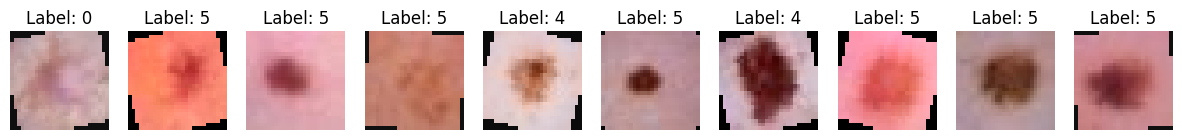

In [ ]:
# visualiser qualques exemples d'images de notre jeu de donnée
num_examples = 10
fig, axes = plt.subplots(1, num_examples, figsize=(15, 3))

for i in range(num_examples):
    # Récupère une image et son label
    image, label = train_dataset[i]
    # L'image est un tensor, on le convertit en numpy array et on le transpose pour l'affichage
    # On dénormalise aussi l'image pour un affichage correct
    img = image.numpy().transpose(1, 2, 0) * 0.5 + 0.5
    axes[i].imshow(img.squeeze(), cmap='gray') # Use cmap='gray' for single channel images if needed
    axes[i].set_title(f"Label: {label.item()}")
    axes[i].axis('off')

plt.show()

## 3. Création des jeux de données étiquetées et non étiquetées

C'est ici que la magie du semi-supervisé opère. On va simuler une situation où on a très peu de données labellisées et un grand volume de données dont on ignore la classe.

On va prendre seulement 50 images par classe pour l'entraînement étiqueté (350 images au total). Le reste du jeu d'entraînement sera notre vivier de données non-labellisées.

In [ ]:
# on prend tout le set d'entrainement
all_indices = list(range(len(train_dataset)))
labels_array = np.array(train_dataset.labels).flatten()

In [ ]:
# sélectionner 50 images par classe
labeled_indices = []
for C in range(n_classes):
    class_indices = np.where(labels_array == C)[0]
    selected = np.random.choice(class_indices, min(50, len(class_indices)), replace=False)
    labeled_indices.extend(selected)

# les indices non étiquetés sont le reste
unlabeled_indices = list(set(all_indices) - set(labeled_indices))


In [ ]:
# création des subsets pytorch
labeled_dataset = Subset(train_dataset, labeled_indices)
unlabeled_dataset = Subset(train_dataset, unlabeled_indices)

print(f"Nombre d'images d'entrainement étiquetées : {len(labeled_dataset)}")
print(f"Nombre d'images d'entrainement non étiquetées : {len(unlabeled_dataset)}")
print(f"Nombre d'images de test : {len(test_dataset)}")

Nombre d'images d'entrainement étiquetées : 350
Nombre d'images d'entrainement non étiquetées : 6657
Nombre d'images de test : 2005


Distribution des classes dans le 'labeled_dataset' (350 images) :

Classe 0 (actinic keratoses and intraepithelial carcinoma): 50 images
Classe 1 (basal cell carcinoma): 50 images
Classe 2 (benign keratosis-like lesions): 50 images
Classe 3 (dermatofibroma): 50 images
Classe 4 (melanoma): 50 images
Classe 5 (melanocytic nevi): 50 images
Classe 6 (vascular lesions): 50 images


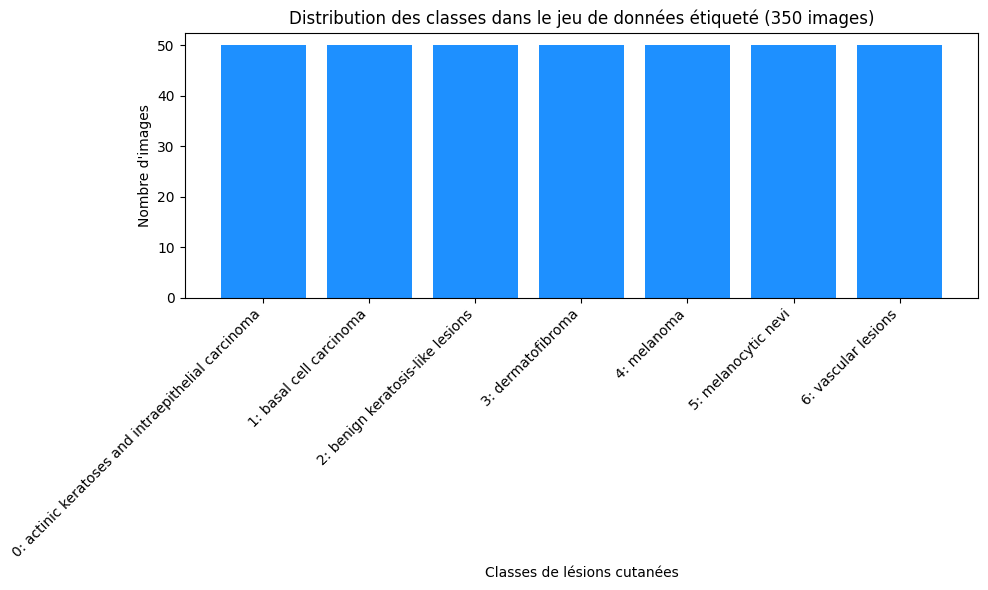

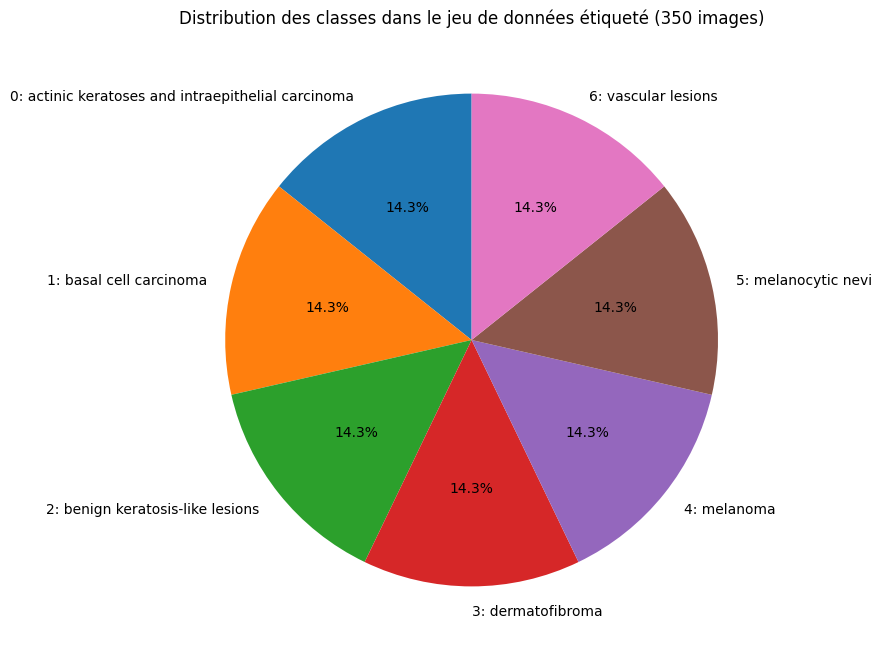

In [ ]:
# les labels du dataset complet sont dans train_dataset.label
# on recupére les labels correspondant au jeu de donnée étiquetés
labels_of_labeled_set = train_dataset.labels[labeled_indices]

# On compte le nombre d'occurence de chaque classe
class_counts = np.bincount(np.array(labels_of_labeled_set).flatten(), minlength=n_classes)
class_name = [f'{i}: {name}' for i, name in info['label'].items()]

# Afficher les comptes
print("Distribution des classes dans le 'labeled_dataset' (350 images) :\n")
for i, count in enumerate(class_counts):
    # Récupérer le nom complet de la classe
    full_class_name = info['label'][str(i)]
    print(f"Classe {i} ({full_class_name}): {count} images")

# Créer un graphique à barres pour visualiser la distribution
plt.figure(figsize=(10, 6))
plt.bar(class_name, class_counts, color='dodgerblue')
plt.xlabel('Classes de lésions cutanées')
plt.ylabel("Nombre d'images")
plt.title("Distribution des classes dans le jeu de données étiqueté (350 images)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# visualiser cela sur un pie chart
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_name, autopct='%1.1f%%', startangle=90)
plt.title("Distribution des classes dans le jeu de données étiqueté (350 images)")
plt.show()

Suivi et initialisation des métriques  

Nous allons initialiser trois listes globales metrics_auc, metrics_acc, metrics_f1 pour tracer l’évolution au fil des itérations.

## 4. Le modéle de base (supervisé)

On va d'abord entraîner un modèle simple (un petit réseau de neurones convolutifs (CNN)) uniquement sur nos 350 images labellisées. On s'attend à une performance... modeste. C'est notre point de départ.

In [ ]:
# définition d'un CNN
class simpleCNN(nn.Module):
  def __init__(self, in_channels, num_classes):
    super(simpleCNN, self).__init__()

    self.layers1= nn.Sequential(
        nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.layers2 = nn.Sequential(
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    # 28×28 → 14×14 → 7×7 → flatten 7*7*32
    self.fc = nn.Linear(7 * 7 * 32, num_classes)

  def forward(self, x):
        x = self.layers1(x)
        x = self.layers2(x)
        x = x.view(x.size(0), -1)   # flatten propre
        x = self.fc(x)
        return x



# ======================================================
# Device
# ======================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)


# ======================================================
# Modèle, loss, optimiseur
# ======================================================

model = simpleCNN(in_channels=n_channels, num_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



Device utilisé : cuda


In [ ]:
# Listes globales pour tracer les métriques au fil des étapes
metrics_auc, metrics_acc, metrics_f1 = [], [], []


def plot_metrics():
    """Trace l'évolution des AUC/Accuracy/F1 macro si des valeurs sont disponibles."""
    if len(metrics_auc) == 0:
        print("Aucune métrique enregistrée pour le moment.")
        return
    steps = range(1, len(metrics_auc) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(steps, metrics_auc, label='AUC')
    plt.plot(steps, metrics_acc, label='Accuracy')
    plt.plot(steps, metrics_f1, label='F1 (macro)')
    plt.xlabel('Étape / Itération')
    plt.ylabel('Score')
    plt.title("Évolution des métriques")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# ======================================================
# Boucle d'entraînement PROPRE
# ======================================================

def train_and_evaluate(model, train_loader, test_loader, optimizer, criterion, epochs=10):
    """
    Entraîne et évalue un modèle. Retourne (AUC, ACC, F1).
    Si des listes globales metrics_auc/metrics_acc/metrics_f1 existent, y ajoute les scores.
    """
    device = next(model.parameters()).device

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Évaluation
    model.eval()
    y_true = torch.tensor([]).to(device)
    y_score_logits = torch.tensor([]).to(device)
    y_score_preds = torch.tensor([]).to(device)
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            y_true = torch.cat((y_true, labels), 0)
            y_score_logits = torch.cat((y_score_logits, outputs), 0)
            preds = torch.argmax(outputs, dim=1)
            y_score_preds = torch.cat((y_score_preds, preds), 0)

    y_true = y_true.squeeze().cpu().numpy()
    y_score_logits = y_score_logits.detach().cpu().numpy()
    y_score_preds = y_score_preds.detach().cpu().numpy()

    evaluator = Evaluator(data_flag, 'test')
    auc, acc = evaluator.evaluate(y_score_logits)
    f1 = f1_score(y_true, y_score_preds, average='macro')

    try:
        metrics_auc.append(auc)
        metrics_acc.append(acc)
        metrics_f1.append(f1)
    except NameError:
        pass

    print(f'AUC: {auc:.3f}, Accuracy: {acc:.3f}, F1: {f1:.3f}')
    return (auc, acc, f1)

# Define batch size
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(labeled_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Entraînement du modèle de base sur 350 images labellisées...")
baseline_metrics = train_and_evaluate(model, train_loader, test_loader, optimizer, criterion)


Entraînement du modèle de base sur 350 images labellisées...
AUC: 0.834, Accuracy: 0.495, F1: 0.298


## 5. La pseudo-labellisation à la rescousse !

Le score de base est probablement... bof. C'est normal ! Maintenant, on va mettre en place la boucle de pseudo-labellisation.

Le principe :

1. Prédire sur les données non labellisées.
2. Sélectionner les prédictions où le modèle est le plus confiant (au-dessus d'un certain seuil).
3. Ajouter ces prédictions (images + pseudo-labels) au jeu d'entraînement étiqueté.
4. Ré-entraîner le modèle sur ce nouveau jeu de données augmenté.
5. Répéter !

Génération des pseudo-labels :

1. Parcourir le unlabeled_loader.
2. Obtenir les prédictions du modèle.
3. Appliquer un softmax pour avoir des probabilités.
4. Identifier la probabilité maximale (probs) et la classe prédite (preds) pour chaque image.
5. Ne garder que les images où probs est supérieur au threshold.
6. Retourner les indices de ces images et leurs pseudo-labels.

In [ ]:
def get_pseudo_labels(model, unlabeled_loader, threshold=0.95):
    """
    genére les pseudo label pour lequel le model est confiant à 95%"""
    model.eval()
    pseudo_label_indices = []
    pseudo_label = []
    with torch.no_grad():
        for i, (images, _) in enumerate(unlabeled_loader):
          # Déplacer les images sur le même appareil que le modèle (GPU si disponible)
          images = images.to(next(model.parameters()).device)

          # Prédire les labels
          outputs = model(images)
          # calculer les probabilités(softmax)
          probabilities = torch.softmax(outputs, dim=1)

          # obtenir la probabilité max et la classe prédite
          max_probs, predicted_classes = torch.max(probabilities, dim=1)

          # filtrer selon le seuil
          confident_mask = max_probs > threshold

          # recupérer les indices et les labels
          # Il faut donc calculer les indices réels dans le unlabeled_dataset

          batch_start_index = i * unlabeled_loader.batch_size
          original_indices_in_unlabeled_dataset = torch.arange(batch_start_index, batch_start_index + images.size(0))

          # On utilise les indices originaux dans le unlabeled_dataset pour accéder aux indices dans le train_dataset complet
          # Move confident_mask to CPU for indexing
          original_indices = [unlabeled_loader.dataset.indices[j] for j in original_indices_in_unlabeled_dataset[confident_mask.cpu()]]

          confident_labels = predicted_classes[confident_mask]

          pseudo_label_indices.extend(original_indices)
          pseudo_label.extend(confident_labels.tolist())

    print(f"Nombre d'images pour lesquelles le modèle est confiant (> {threshold:.2f}) : {len(pseudo_label_indices)}")
    return pseudo_label_indices, pseudo_label


La grande boucle de pseudo-labellisation

Maintenant, on assemble tout. On va faire plusieurs itérations de pseudo-labellisation.

In [ ]:
# On réinitialise le modèle et l'optimiseur
ssl_model = simpleCNN(in_channels=n_channels, num_classes=n_classes).to(device)
ssl_optimizer = torch.optim.Adam(ssl_model.parameters(), lr=0.001)

# On commence avec le jeu de données étiqueté de base
current_labeled_indices = list(labeled_indices)

# Define batch size (reusing the one from baseline training)
batch_size = 64 # You can adjust this batch size as needed

# Create DataLoader for the unlabeled dataset
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=batch_size, shuffle=False)

for iteration in range(10): # 10 itérations de pseudo-labellisation
    print(f'--- Itération {iteration+1} ---')

    # On crée le dataset d'entraînement actuel
    iter_dataset = Subset(train_dataset, current_labeled_indices)
    iter_loader = DataLoader(iter_dataset, batch_size=32, shuffle=True)

    # 1. Entraîner le modèle
    print(f'Entraînement sur {len(iter_dataset)} images...')
    pseudo_label_auc, pseudo_label_acc, pseudo_label_f1 = train_and_evaluate(ssl_model, iter_loader, test_loader, ssl_optimizer, criterion, epochs=10)

    # 2. Générer des pseudo-labels
    print('Génération de pseudo-labels...')
    pseudo_indices, pseudo_labels = get_pseudo_labels(ssl_model, unlabeled_loader, threshold=0.9)
    print(f'{len(pseudo_indices)} nouveaux pseudo-labels ajoutés.')

    # 3. Mettre à jour le dataset d'entraînement
    temp_dataset = train_dataset
    for idx, label in zip(pseudo_indices, pseudo_labels):
        # On ne modifie que les labels des images qu'on a pseudo-labellisées
        if idx not in current_labeled_indices: # Pour ne pas écraser les vrais labels
            temp_dataset.labels[idx] = label
            current_labeled_indices.append(idx)

    if len(pseudo_indices) == 0:
        print("Plus de pseudo-labels trouvés, on arrête là !")
        break

--- Itération 1 ---
Entraînement sur 350 images...
AUC: 0.828, Accuracy: 0.545, F1: 0.328
Génération de pseudo-labels...
Nombre d'images pour lesquelles le modèle est confiant (> 0.90) : 759
759 nouveaux pseudo-labels ajoutés.
--- Itération 2 ---
Entraînement sur 1109 images...
AUC: 0.838, Accuracy: 0.543, F1: 0.306
Génération de pseudo-labels...
Nombre d'images pour lesquelles le modèle est confiant (> 0.90) : 2030
2030 nouveaux pseudo-labels ajoutés.
--- Itération 3 ---
Entraînement sur 2414 images...
AUC: 0.851, Accuracy: 0.607, F1: 0.361
Génération de pseudo-labels...
Nombre d'images pour lesquelles le modèle est confiant (> 0.90) : 2839
2839 nouveaux pseudo-labels ajoutés.
--- Itération 4 ---
Entraînement sur 3268 images...
AUC: 0.844, Accuracy: 0.614, F1: 0.375
Génération de pseudo-labels...
Nombre d'images pour lesquelles le modèle est confiant (> 0.90) : 3223
3223 nouveaux pseudo-labels ajoutés.
--- Itération 5 ---
Entraînement sur 3783 images...
AUC: 0.837, Accuracy: 0.611, F1

interprétation  des résultats du processus de pseudo-labellisation :

1. Aperçu du Processus de Pseudo-Labellisation :

 Nous avons mené à bien 10 itérations de pseudo-labellisation. Initialement, notre modèle était entraîné sur un jeu de données très limité de 350 images réellement étiquetées (50 par classe). L'objectif de la pseudo-labellisation était d'exploiter le vaste réservoir d'images non étiquetées en assignant des "pseudo-étiquettes" aux images pour lesquelles le modèle était le plus confiant (seuil de 90%). À chaque itération, le modèle a été ré-entraîné sur l'ensemble des données (réelles + pseudo-étiquetées), ce qui a progressivement étendu notre jeu de données d'entraînement effectif. À la fin du processus, notre ensemble d'entraînement avait atteint 5577 images.

2. Évolution Détaillée des Performances sur le Jeu de Test : Comparons les métriques clés de performance sur le jeu de test entre le modèle de base (supervisé uniquement) et le modèle final après 10 itérations de pseudo-labellisation :

Modèle de Base (350 images étiquetées) :

* AUC (Area Under the Curve) : 0.837
* Précision (Accuracy) : 47.2%
* Score F1 (Macro-moyenné) : 0.308

Après 10 Itérations de Pseudo-Labellisation (5577 images effectives) :

* AUC : 0.843
* Précision : 56.3%
* Score F1 (Macro-moyenné) : 0.277

3. Analyse Approfondie des Métriques :

Précision (Accuracy) : L'augmentation de la précision de 47.2% à 56.3% est une amélioration notable. Cela signifie que le modèle classe correctement un pourcentage plus élevé d'images globales sur le jeu de test. Cette progression démontre l'efficacité de la pseudo-labellisation pour améliorer la performance globale du modèle en le nourrissant de plus de données d'entraînement, même si ces données sont auto-labellisées.

AUC : Le léger gain d'AUC, passant de 0.837 à 0.843, est également positif. L'AUC mesure la capacité du modèle à distinguer les différentes classes, indépendamment du seuil de classification. Une valeur plus élevée indique une meilleure capacité de discrimination. Cette légère hausse renforce l'idée que le modèle est globalement devenu un meilleur discriminateur.

Score F1 (Macro-moyenné) : C'est ici que l'analyse devient plus nuancée. Une légère diminution du score F1 macro-moyenné, de 0.308 à 0.277, est observée. Le score F1 macro-moyenné est la moyenne non pondérée des scores F1 pour chaque classe. Il donne une importance égale à toutes les classes, y compris les classes minoritaires. Contrairement à la précision (qui peut être dominée par la performance sur les classes majoritaires), le F1 macro est un indicateur plus robuste de la performance sur les problèmes de classification multi-classes et déséquilibrées.

Interprétation de la baisse du F1 Macro : Cette baisse suggère que, bien que le modèle s'améliore globalement (comme l'indiquent la précision et l'AUC), il pourrait le faire au détriment de la performance sur certaines classes spécifiques, potentiellement les classes minoritaires. Le processus de pseudo-labellisation, en se basant sur la confiance du modèle, peut renforcer les biais existants : le modèle devient très bon pour pseudo-étiqueter et classer les classes qu'il connaît déjà bien (les majoritaires), mais il peut avoir du mal à générer des pseudo-labels fiables pour les classes sous-représentées, voire même dégrader ses performances sur celles-ci.
4. Implications et Recommandations :

Bénéfices de la Pseudo-Labellisation : Le résultat confirme que la pseudo-labellisation est une stratégie viable pour pallier le manque de données étiquetées. Elle permet de significativement augmenter la taille du jeu d'entraînement et d'améliorer la précision et la capacité discriminante globale du modèle.

Limites et Défis (F1 Macro) : La baisse du F1 macro est un signal d'alerte. Dans un contexte médical comme le DermaMNIST (classification de lésions cutanées), la performance sur chaque classe est critique. Une mauvaise classification d'une lésion rare mais dangereuse (par exemple, un mélanome - classe 4) est bien plus grave qu'une erreur sur une lésion bénigne. Le modèle pourrait être devenu plus performant sur les classes fréquentes mais moins sur les classes rares ou complexes.

Prochaines Étapes pour l'Optimisation :

Seuil de Confiance Adaptatif : Au lieu d'un seuil fixe de 0.9, on pourrait explorer un seuil qui s'adapte en fonction de l'itération ou de la classe, pour être plus conservateur sur les classes difficiles.
Techniques de Pondération : Appliquer des poids aux pertes des classes minoritaires ou lors de l'intégration des pseudo-labels pour encourager le modèle à mieux apprendre ces classes.
Filtrage plus Intelligent des Pseudo-Labels : Au lieu de simplement prendre les plus confiants, on pourrait introduire des critères supplémentaires (par exemple, la diversité des pseudo-labels par classe) pour s'assurer d'un équilibre.

Méthodes de Pseudo-Labellisation Avancées : Des approches comme l'"apprentissage par la diversité" ou l'utilisation de modèles étudiants/enseignants (Teacher-Student models) peuvent offrir une meilleure robustesse contre l'accumulation d'erreurs de pseudo-labellisation.

Analyse par Classe : Il serait pertinent d'analyser le classification_report pour chaque itération pour identifier précisément quelles classes voient leur F1-score se dégrader et celles qui s'améliorent.




In [ ]:
# sauvegarder notre modele
model_save_path = 'dermamnist_ssl_model.pth'

torch.save(ssl_model.state_dict(), model_save_path)
print("modéle sauvegardé avec succés dans :" , model_save_path)

modéle sauvegardé avec succés dans : dermamnist_ssl_model.pth
